<a href="https://colab.research.google.com/github/adasegroup/ML2023_seminars/blob/master/seminar12/attention_seminar_part1/attention_seminar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Attention and transformers

**Plan for today:**

1. theory recap
2. Attention mechanism
3. Using transformers for applied tasks
4. (bonus) pre-trained transformers from Hugging Face

## Theory Recap

### Embeddings

All text need to be divided into **tokens**. A **token** is a minimal unit of textual information, often a word or part of a word.

To vectorize a token into a numerical vector, you need to get embedding of the token from embedding layer.

Word **embeddings** are representation vectors for words in a lower-dimensional space.

**Embedding layer** is a trainable matrix. TO get embedding of the token you need to take an appropriate row according to token ID.

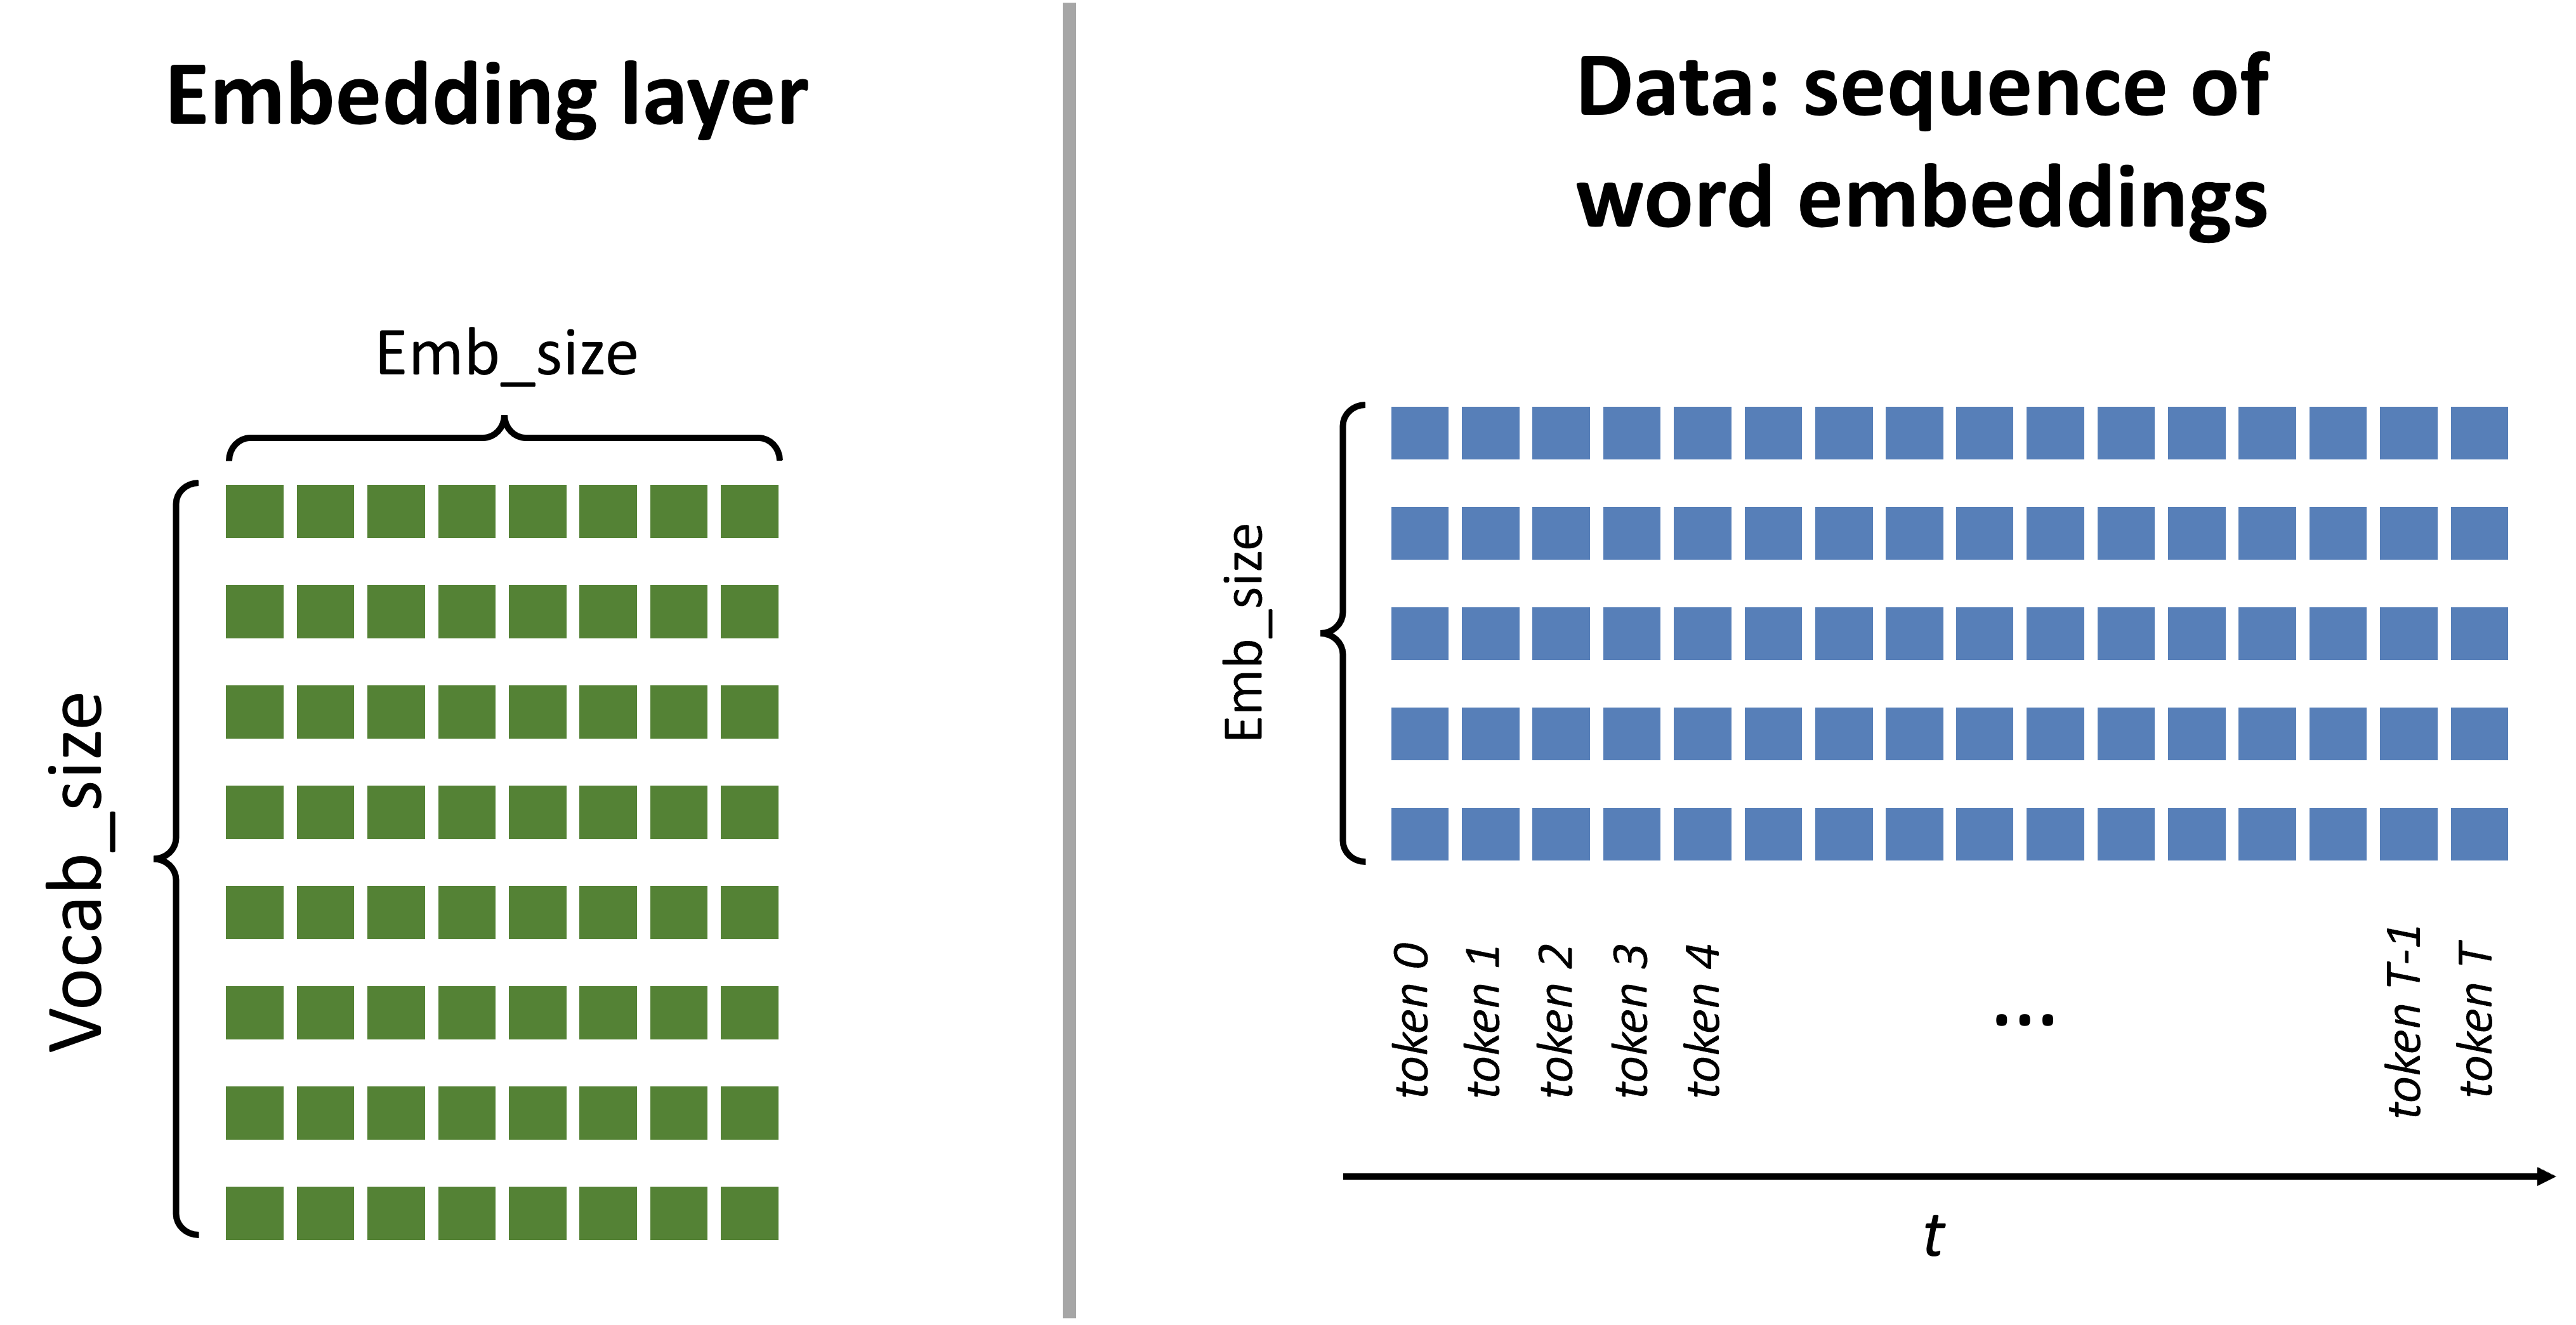

Well trained embeddings can have interesting characteristic. For example, if you find difference between vectors of words "Man" and "Woman", you can get similar vector to difference between vectors "King" and "Queen". It demonstrates that embeddings save relationships between words.

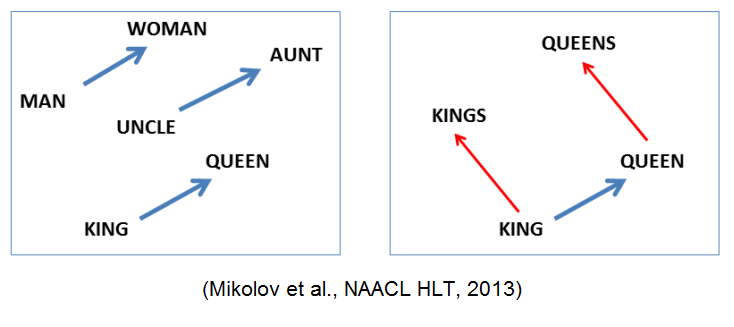

### Key concepts of attention

Attention is based on three core objects **query, key, value**.

Attention principles are very naturals and could be interpreted as:

1. Query - what you want to find (decoder)
2. Key - representation of data (encoder)
3. Value - the importance of the object in data (encoder)

The query is what you want to find in a date, key - represents data for query search, and value is information stored in an object. A natural example could be illustrated in the machine translation task.

![language-model.png](https://raw.githubusercontent.com/zaaabik/msd2021/main/attention_sentence.png)

In this picture, queries from one language have bigger attention for words with the same meaning but in a different language.

### Transformer architecture

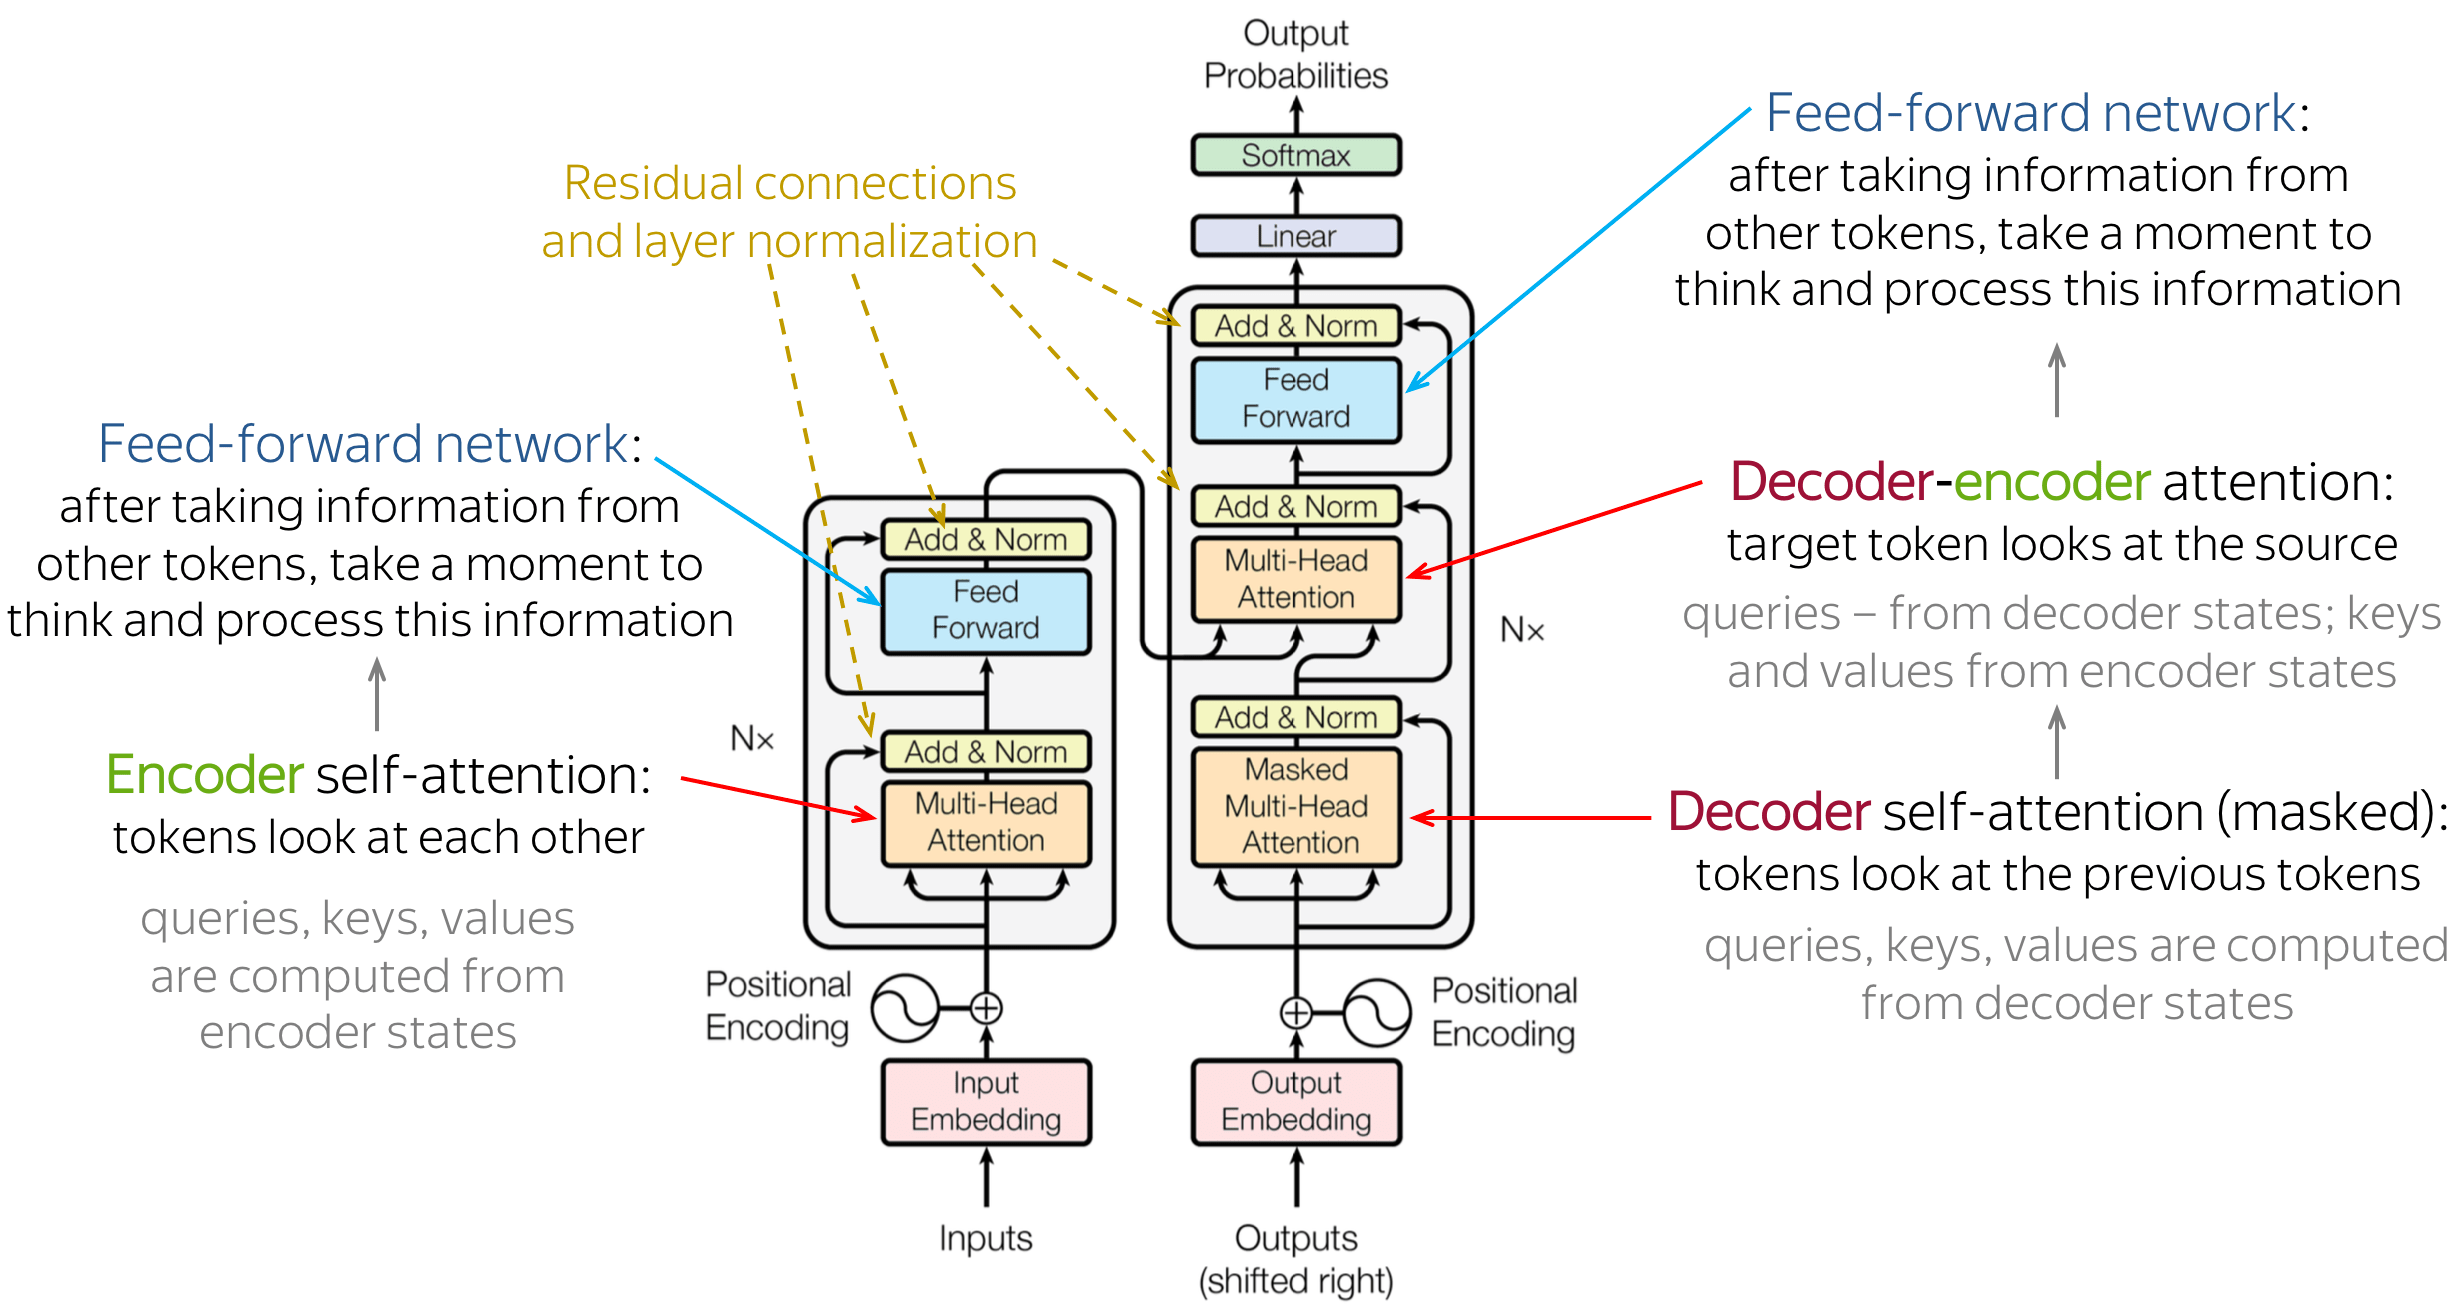

## Lets go into details!



### Similarity coefficient
First of all, we need to compute the similarity coefficient between each query and key.

\begin{align}
 cᵢⱼ = f(qᵢ, kⱼ)
\end{align}
where $c$ is similairty coefficient between $i$-query with $j$ key.

Function $f$ could be an arbitrary function that returns the real number and describes two elements' similarities.

### Attention weights
For each $ q_i $, we compute similarity coefficient with whole keys and obtain vector from $ R^{n} $, where n - number of keys.
\begin{align}
 C_i  = [c_{i 1}, c_{i 2} ... c_{i n}]
\end{align}

One of the problems is that elements in $ C_i $ could be on a different scale. So, we want to map the sum into $(0, 1)$ and interpret elements as a probability. To do it, we use the softmax function:

\begin{align}
a_{ij} = \frac{\text{exp}(c_{i j})}{\sum_{k=1}^{n} \text{exp}(с_{in})}
\end{align}

\begin{align}
A_i  = softmax(C_i) = softmax([c_{i 1}, c_{i 2} ... c_{i n}])
\end{align}

### Attention matrix
Finally we get an attention matrix, where each row is softmaxed similarity coefficent of one query with all keys.

\begin{align}
A_i  = [
    A_1,\\
    A_2,\\
    ...\\
    A_{n - 1}\\
    A_n]
\end{align}

### Attention output



The output of the attention block is a weighted sum of values.
\begin{align}
 O_k = \sum^n_{i = 1} a_{k i} v_i = A_k V
\end{align}

## Lets code!

In [ ]:
!pip install numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 64.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.

# **!!!RESTART THE CURRENT SESSION!!!**

In [ ]:
import numpy
numpy.__version__

'1.26.4'

numpy should have the version 1.26.4

In [ ]:
!pip install gensim
!pip install -U torchdata
!pip install -U spacy
!python -m spacy download en_core_web_sm
!python -m spacy download de_core_news_sm
!pip install portalocker>=2.0.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 44.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 124.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 70.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
!pip install -U torchtext==0.16.2 #0.15.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.4/755.4 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.4/184.4 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Transformer
from tqdm.auto import tqdm

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

### Similarity coefficient
We should create a function that takes two vectors with the same shape and return a real value. The most straightforward measure is the dot product.

### Dot product attention
The core idea is to use a scaled dot product as a similarity coefficient.

\begin{align}
c  =  \frac{\langle \mathbf{q}, \mathbf{k} \rangle}{\sqrt{d}}
\end{align}
The function takes two vectors with the same dimension $q, k \in R^d$, and compute dot product and device by dimension size. Dividing helps reduce std difference for vectors with different size and make the function more general.

#### task 1.1 Implement similarity function

In [ ]:
torch.manual_seed(0)

d = 256
q = torch.rand(d)
k = torch.rand(d)

def scalar_similarity_coefficient(q, k, d):
    ## TODO write scaled dot product
    return torch.dot(q, k) / np.sqrt(d)

similarity_score = scalar_similarity_coefficient(q, k, d)
assert(
    torch.allclose(similarity_score,
                   torch.tensor(3.854549))
)

In [ ]:
similarity_score

tensor(3.8545)

let's check function with real data. We can take pre-trained embeddings from model [GloVe](https://en.wikipedia.org/wiki/GloVe) and estimate attention function with it.

In [ ]:
from gensim.models import KeyedVectors
from gensim.downloader import load

glove_model = load('glove-wiki-gigaword-50')

[==================================================] 100.0% 66.0/66.0MB downloaded


In [ ]:
def get_embeddings(words, model, add_mask=False, emb_size=50):

    embeddings = np.zeros((len(words), emb_size))

    if add_mask:
        mask = np.ones(len(words))
    for i, word in enumerate(words):
        if word == 'PAD':
            mask[i] = 0
            embeddings[i] = np.random.normal(emb_size)
        else:
            try:
                emb = glove_model[word]
            except:
                emb = np.random.normal(emb_size)
            embeddings[i] = emb

    if add_mask:
        return embeddings, mask
    else:
        return embeddings


In [ ]:
words = ['cat', 'try', 'catch', 'mouse']  # Example word sequence
input_sequence = get_embeddings(words, glove_model)
input_sequence.shape

(4, 50)

Let's visualize embeddings

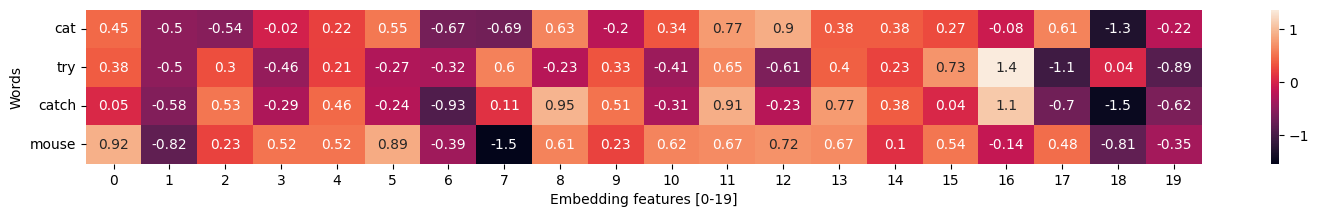

In [ ]:
plt.figure(figsize=(18, 2))
sns.heatmap(input_sequence[:, :20].round(2), yticklabels=words, annot=True)
plt.yticks(rotation=0)
plt.ylabel('Words')
plt.xlabel('Embedding features [0-19]')
plt.show()

Check our code with embeddings

In [ ]:
d = input_sequence.shape[1] # Embedding size
q = torch.tensor(input_sequence[0], dtype=torch.float32) # Embedding of word "cat"
k = torch.tensor(input_sequence[3], dtype=torch.float32) # Embedding of word "mouse"

similarity_score = scalar_similarity_coefficient(q, k, d)

assert(
    torch.allclose(similarity_score,
                   torch.tensor(2.3490))
)

To compute coefficient for multiple queries and keys efficient, we need to rewrite all in **vectorized form**.

We assume  $q \in R^{b, t, d}$ and $ k \in R^{b, k, d} $ where $b$ - batch size, $t$ and $k$ - number of queries and keys, $d$ - the shape of the data.

PyTorch framework has the function for multiplication elements in a batch manner.

`torch.bnn(tensor1, tensor2)`
, where tensor1 is a $ (b \times n \times m) $ and tensor2 is a $ (b \times m \times p) $ . This function produce matrix multiplication for each object in a batch independent and output has shape $(b \times  n \; x \times p)$

#### task 1.2 Implement similarity function

In [ ]:
## imagine that we have 10 queries and 8 keys and need to construce matrix of cofficent.

torch.manual_seed(0)
d = 64
t, k = 10, 8
batch_size = 3
query = torch.rand(t, d)
query = query.repeat(batch_size, 1, 1)

key = torch.rand(k, d)
key = key.repeat(batch_size, 1, 1)

def compute_coefficient_matrix(query, key, d):
    ## TODO write vectorized scaled dot product
    return query @ key.transpose(-1, -2) / np.sqrt(d)

coefficient_matrix = compute_coefficient_matrix(query, key, d)

second_query = query[0, 2]
third_key = key[0, 3]

assert torch.allclose(coefficient_matrix[0, 2, 3], scalar_similarity_coefficient(second_query, third_key, d))
assert torch.allclose(coefficient_matrix[0], coefficient_matrix[1])
assert torch.Size([batch_size, t,k]) == coefficient_matrix.shape

real data example

In [ ]:
words_0 = ['cat', 'try', 'catch', 'mouse']  # Example word sequence
input_sequence_0 = get_embeddings(words_0, glove_model)

words_1 = ['mouse', 'like', 'eat', 'cheese']  # Example word sequence
input_sequence_1 = get_embeddings(words_1, glove_model)

batch_input_seq = np.concatenate([input_sequence_0, input_sequence_1])
batch_input_seq = batch_input_seq.reshape(2, 4, 50) # BS x Seq len x Emb Size
batch_input_seq.shape

(2, 4, 50)

In [ ]:
query = torch.tensor(batch_input_seq)
key = torch.tensor(batch_input_seq)

coefficient_matrix = compute_coefficient_matrix(query, key, d)
coefficient_matrix.shape

torch.Size([2, 4, 4])

Draw a plot of attention matrix

In [ ]:
def plot_attention_heatmap(attention_weights, words=None, smx=False):
    plt.figure(figsize=(6, 5))
    if not words:
         words = np.arange(attention_weights.shape[0])
    vmin =  0 if smx else torch.min(attention_weights)
    vmax = 1 if smx else torch.max(attention_weights)

    sns.heatmap(attention_weights.detach().numpy(),
                xticklabels=words,
                yticklabels=words,
                vmin=vmin,
                vmax=vmax,
                cmap="YlGnBu",
                annot=True,
                fmt=".2f")
    plt.title("Attention Scores Heatmap")
    plt.xlabel("Key Tokens")
    plt.ylabel("Query Tokens")
    plt.show()

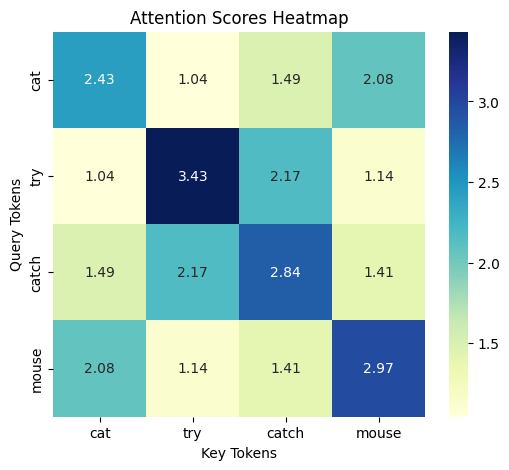

In [ ]:
plot_attention_heatmap(coefficient_matrix[0], words_0)

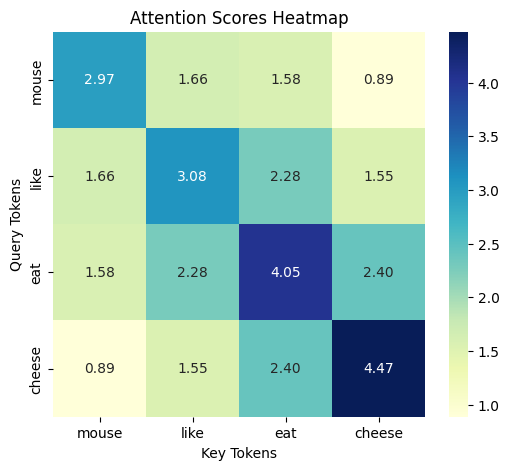

In [ ]:
plot_attention_heatmap(coefficient_matrix[1], words_1)

Let's check, why we need to use matrix multiplications

In [ ]:
def slow_non_vector_compute_coefficient_matrix(query, key, d):
    b_s, q_l, _ = query.shape
    _, k_l, _ = key.shape
    out = torch.zeros(b_s, q_l, k_l)

    for b in range(b_s):
        for q in range(q_l):
            for k in range(k_l):
                current_query = query[b, q]
                current_key = key[b, k]
                out[b, q, k] = scalar_similarity_coefficient(current_query, current_key, d)
    return out


In [ ]:
d = 64
t, k = 32, 10
batch_size = 128

query = torch.rand(batch_size, t, d)
key = torch.rand(batch_size, k, d)

In [ ]:
%%time
slow_attention_results = slow_non_vector_compute_coefficient_matrix(query, key, d)

CPU times: user 1.51 s, sys: 2.94 ms, total: 1.52 s
Wall time: 1.53 s


In [ ]:
%%time
fast_attention_result = compute_coefficient_matrix(query, key, d)

CPU times: user 1.28 ms, sys: 25 µs, total: 1.31 ms
Wall time: 809 µs


Using vectorization significant reduce attention computation time.

In [ ]:
assert torch.allclose(slow_attention_results, fast_attention_result)

After getting the coefficient matrix, we need to transform it into probabilities by applying the softmax function. Each row contains a coefficient between one query and all keys, which should be a probability distribution.

#### task 2. calculate attention matrix with softmax efficiently

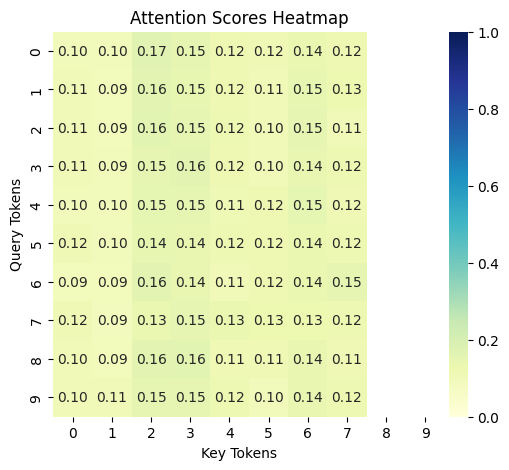

In [ ]:
## imagine that we have 10 queries and 8 keys and need to construce matrix of cofficent.

torch.manual_seed(2)
d = 64
t,k = 10, 8
batch_size = 3
query = torch.rand(batch_size, t, d)
key = torch.rand(batch_size, k, d)

def compute_attention_matrix(query, key, d):
    coefficient_matrix = compute_coefficient_matrix(query, key, d)
    ## TODO apply softmax
    attention_matrix = torch.softmax(coefficient_matrix, dim=-1)
    return attention_matrix

A = compute_attention_matrix(query, key, d)

assert np.allclose((A.sum(axis=-1) - 1).sum().numpy(), 0, atol=1e-6)
assert torch.all(A >= 0.0)

plot_attention_heatmap(A[0], smx=True)

And let's look with real data

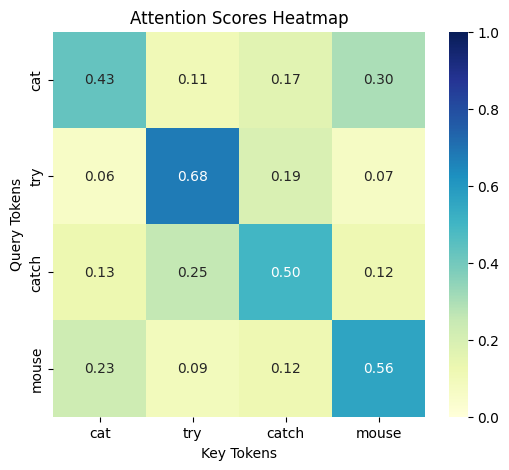

In [ ]:
query = torch.tensor(batch_input_seq)
key = torch.tensor(batch_input_seq)

attention_matrix = compute_attention_matrix(query, key, d)
plot_attention_heatmap(attention_matrix[0], words_0, smx=True)

In this image attention, distribution should be almost uniform as we randomly initialize all elements, and the attention coefficient should be similar for all elements.

The last step is to use attention weights to compute the weighted sum of values. Sum each value with coefficient taken from the attention matrix.

\begin{align}
 O_k = \sum^n_{i = 1} a_{k i} v_i = A_k V
\end{align}
 where k - is a number of attention output

In [ ]:
## imagine that we have 10 queries and 8 keys and need to construce matrix of cofficent.

torch.manual_seed(6)
d = 64
t,k = 10, 8
batch_size = 3
query = torch.rand(batch_size, t, d)
key = torch.rand(batch_size, k, d)
value = torch.rand(batch_size, k, d)

def attention(query, key, value, d):
    coefficient_matrix = compute_coefficient_matrix(query, key, d)
    attention_matrix = torch.softmax(coefficient_matrix, dim=-1)
    out = attention_matrix @ value
    return attention_matrix, out


A, out = attention(query, key, value, d)
assert out.shape == query.shape
assert torch.allclose(out.sum(), torch.tensor(973.154541015625))

### Attention layer
To help attention find interesting patterns in data, we use linear projections to create queries, keys and values. A model can train such a projection matrix and describe data in the best way to solve the problem.

\begin{align}
q = w_q x_q + b_q \\
k = w_k x_k + b_k \\
v = w_v x_v + b_v \\
\end{align}
where $ w_q, w_k, w_v \in R^{n,n}$

The following steps are the same with attention.

#### task 3. Implement attention layer

In [ ]:
class AttentionLayer(torch.nn.Module):
    def __init__(self, d):
        super().__init__()
        self.q_layer = torch.nn.Linear(d, d) ## TODO trainiable projection layer
        self.k_layer = torch.nn.Linear(d, d) ## TODO trainiable projection layer
        self.v_layer = torch.nn.Linear(d, d) ## TODO trainiable projection layer
        self.d = d

    def forward(self, query_data, key_data, value_data):
        self.q_proj = self.q_layer(query_data)
        self.k_proj = self.k_layer(key_data)
        self.v_proj = self.v_layer(value_data)

        self.A, out = attention(self.q_proj, self.k_proj, self.v_proj, self.d)
        return out

d = 32
t, k = 10, 8
batch_size = 3
query_data = torch.rand(batch_size, t, d) # batch_size x seq_len x feature_size
key_data = torch.rand(batch_size, k, d) # batch_size x seq_len x feature_size
value_data = torch.rand(batch_size, k, d) # batch_size x seq_len x feature_size


att_layer = AttentionLayer(d)
att_layer_output = att_layer(query_data, key_data, value_data)

assert att_layer_output.shape == query_data.shape
assert not torch.allclose(attention(query_data, key_data, value_data, d)[1], att_layer_output)

### Self-attention
Attention mechanism does not suggest any restriction for input data, and a large number of modern architectures use attention when all $x_q, x_k, x_v$ the same input data. In this case query, key, the value produced by the same source but after application of trainable projection matrix represent data from a different point of view.

\begin{align}
q = w_q x \\
k = w_k x \\
v = w_v x \\
\end{align}

In [ ]:
d = 32
t = 10
batch_size = 3
x = torch.rand(batch_size, t, d)

att_layer = AttentionLayer(d)
att_layer_output = att_layer(x, x, x)

### Masked attention

There are many datasets where sequence length is different in real life, but we still need batch processing to make a model work fast and efficient. For this purpose, we use padding for a sequence.

![padded_sequence.png](https://raw.githubusercontent.com/zaaabik/msd2021/main/padded_sequence.png)

Our task is to create a model that pushes the model to ignore padding elements and make attention for them equal to zero.

![masked_non_masked_attention.png](https://raw.githubusercontent.com/zaaabik/msd2021/main/masked_non_masked_attention.png)

Your task is:


1.   Pad keys and values using
`torch.nn.utils.rnn.pad_sequence(sequences, batch_first=False, padding_value=0.0)`. **Use parameter batch_first=True, to make output compatible with our attention function**
2.   Create a mask for keys and values, which help you make zeros in the attention matrix. To change the number in the attention matrix, you can use
`Tensor.masked_fill_(mask, value). This function takes Tensor and boolean masks with the same shape and then fills tensor elements with value parameters where the mask is True.



In [ ]:
def masked_attention(query, key, value, mask, d):
    coefficient_matrix = compute_coefficient_matrix(query, key, d)

    ## TODO: make an masked attention
    if mask is not None:
        coefficient_matrix = coefficient_matrix.masked_fill(
            mask == 0, float("-1e20")
        )
    attention_matrix = torch.softmax(coefficient_matrix, dim=-1)


    out = attention_matrix @ value
    return attention_matrix, out


Look in real data

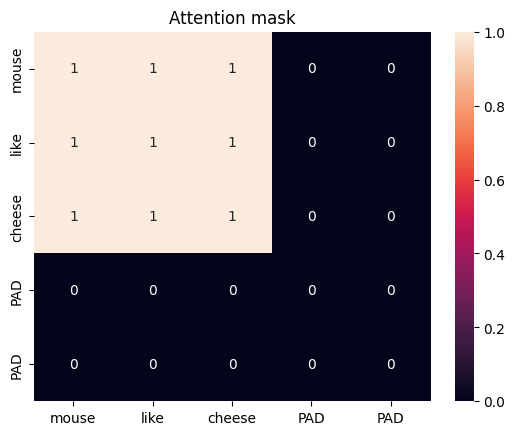

In [ ]:
words_0 = ['cat', 'try', 'catch', 'the', 'mouse']
input_sequence_0, mask_0 = get_embeddings(words_0, glove_model, add_mask=True)

words_1 = ['mouse', 'like', 'cheese', 'PAD', 'PAD']
input_sequence_1, mask_1 = get_embeddings(words_1, glove_model, add_mask=True)

batch_input_seq = np.concatenate([input_sequence_0, input_sequence_1])
batch_input_seq = batch_input_seq.reshape(2, 5, 50) # BS x Seq len x Emb Size

batch_mask = np.hstack([mask_0, mask_1])
batch_attention_mask = batch_mask.reshape(2, -1, 1) @ batch_mask.reshape(2, 1, -1)

plt.title('Attention mask')
sns.heatmap(batch_attention_mask[1], annot=True, xticklabels=words_1, yticklabels=words_1)
plt.show()

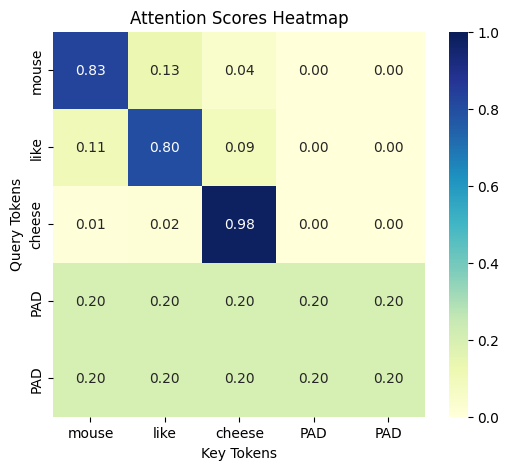

In [ ]:
query = torch.tensor(batch_input_seq)
key = torch.tensor(batch_input_seq)
value = torch.tensor(batch_input_seq)

batch_attention_mask = torch.tensor(batch_attention_mask)

attention_matrix, out = masked_attention(query, key, value, batch_attention_mask, d)
plot_attention_heatmap(attention_matrix[1], words_1, smx=True)

Write masked attention

In [ ]:
class MaskedAttentionLayer(torch.nn.Module):
    def __init__(self, d):
        super().__init__()
        self.q_layer = torch.nn.Linear(d, d)
        self.k_layer = torch.nn.Linear(d, d)
        self.v_layer = torch.nn.Linear(d, d)
        self.d = d

    def forward(self, query_data, key_data, value_data, mask=None):
        self.q_proj = self.q_layer(query_data)
        self.k_proj = self.k_layer(key_data)
        self.v_proj = self.v_layer(value_data)

        self.A, out = masked_attention(self.q_proj, self.k_proj, self.v_proj, mask, self.d)
        return out

d = 32
t, k = 10, 8
batch_size = 3
query_data = torch.rand(batch_size, t, d) # batch_size x seq_len x feature_size
key_data = torch.rand(batch_size, k, d) # batch_size x seq_len x feature_size
value_data = torch.rand(batch_size, k, d) # batch_size x seq_len x feature_size

mask = torch.tril(torch.ones((t, t))).expand(
            batch_size, 1, t, t
)

att_layer = MaskedAttentionLayer(d)
att_layer_output = att_layer(query_data, key_data, value_data)

assert att_layer_output.shape == query_data.shape
assert not torch.allclose(attention(query_data, key_data, value_data, d)[1], att_layer_output)

## Evaluate real transformer!

In [ ]:
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torchtext.datasets import multi30k, Multi30k
from typing import Iterable, List

# We need to modify the URLs for the dataset since the links to the original dataset are broken
# Refer to https://github.com/pytorch/text/issues/1756#issuecomment-1163664163 for more info
multi30k.URL["train"] = "https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/Multi30k/training.tar.gz"
multi30k.URL["valid"] = "https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/Multi30k/validation.tar.gz"

# choose languages of translation
source_language = 'de'
target_language = 'en'

token_transform = {}
vocab_transform = {}

In [ ]:
# Get two tokenizers for different languages
token_transform[source_language] = get_tokenizer('spacy', language='de_core_news_sm')
token_transform[target_language] = get_tokenizer('spacy', language='en_core_web_sm')

def yield_tokens(data_iter: Iterable, language: str) -> List[str]:
    language_index = {source_language: 0, target_language: 1}

    for data_sample in data_iter:
        yield token_transform[language](data_sample[language_index[language]])

# Special Tokens
UNK_IDX = 0  # Token for unknown word
PAD_IDX = 1  # Padding token
SOS_IDX = 2  # Start Of Sequence token
EOS_IDX = 3  # End Of Sequence token

# Define special tokens
special_symbols = ['<unk>', '<pad>', '<sos>', '<eos>']

# Create a vocabulary for each language containing all words and tokens
for ln in [source_language, target_language]:
    train_iter = Multi30k(
        split='train',
        language_pair=(source_language, target_language)
    )

    vocab_transform[ln] = build_vocab_from_iterator(
        yield_tokens(train_iter, ln),
        min_freq=1,
        specials=special_symbols,
        special_first=True
    )

# Specify how to handle unknown words (replace them with <unk>)
for ln in [source_language, target_language]:
    vocab_transform[ln].set_default_index(UNK_IDX)

In [ ]:
token_transform['en']('i like cats and dogs,')

['i', 'like', 'cats', 'and', 'dogs', ',']

In [ ]:
vocab_transform

{'de': Vocab(), 'en': Vocab()}

#### Creating transformer model

##### embeddings blocks

In [ ]:
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super(TokenEmbedding, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)

    def forward(self, x):
        out = self.embedding(x)
        return out

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(
            self,
            emb_size: int,
            dropout: float,
            maxlen: int = 5000
        ):
        super(PositionalEncoding, self).__init__()
        den = torch.exp(- torch.arange(0, emb_size, 2) * np.log(10000) / emb_size)
        pos = torch.arange(0, maxlen).reshape(maxlen, 1)
        pos_embedding = torch.zeros((maxlen, emb_size))
        pos_embedding[:, 0::2] = torch.sin(pos * den)
        pos_embedding[:, 1::2] = torch.cos(pos * den)
        pos_embedding = pos_embedding.unsqueeze(-2)

        self.dropout = nn.Dropout(dropout)
        self.register_buffer('pos_embedding', pos_embedding)

    def forward(self, token_embedding):
        return self.dropout(token_embedding + self.pos_embedding[:token_embedding.size(0), :])

In [ ]:
# Seq2Seq Network
class Seq2SeqTransformer(nn.Module):
    def __init__(
        self,
        num_encoder_layers: int,
        num_decoder_layers: int,
        emb_size: int,
        nhead: int,
        src_vocab_size: int,
        tgt_vocab_size: int,
        dim_feedforward: int = 512,
        dropout: float = 0.1
    ):
        super(Seq2SeqTransformer, self).__init__()
        self.transformer = Transformer(
            d_model=emb_size,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout
        )

        self.generator = nn.Linear(emb_size, tgt_vocab_size)
        self.src_tok_emb = TokenEmbedding(src_vocab_size, emb_size)
        self.tgt_tok_emb = TokenEmbedding(tgt_vocab_size, emb_size)
        self.positional_encoding = PositionalEncoding(
            emb_size, dropout=dropout)

    def forward(
            self,
            src,
            trg,
            src_mask,
            tgt_mask,
            src_padding_mask,
            tgt_padding_mask,
            memory_key_padding_mask
        ):
        src_emb = self.positional_encoding(self.src_tok_emb(src))
        tgt_emb = self.positional_encoding(self.tgt_tok_emb(trg))
        outs = self.transformer(
            src_emb,
            tgt_emb,
            src_mask,
            tgt_mask,
            None,
            src_padding_mask,
            tgt_padding_mask,
            memory_key_padding_mask
        )
        return self.generator(outs)

    def encode(self, src, src_mask):
        return self.transformer.encoder(
            self.positional_encoding(self.src_tok_emb(src)), src_mask
        )

    def decode(self, tgt, memory, tgt_mask):
        return self.transformer.decoder(
            self.positional_encoding(self.tgt_tok_emb(tgt)), memory, tgt_mask
    )

### Training

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
def generate_square_subsequent_mask(sz):
    mask = (torch.triu(torch.ones((sz, sz), device=device)) == 1).transpose(0, 1)
    mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
    return mask

def create_mask(src, tgt):
    src_seq_len = src.shape[0]
    tgt_seq_len = tgt.shape[0]

    tgt_mask = generate_square_subsequent_mask(tgt_seq_len)
    src_mask = torch.zeros((src_seq_len, src_seq_len),device=device).type(torch.bool)

    src_padding_mask = (src == PAD_IDX).transpose(0, 1)
    tgt_padding_mask = (tgt == PAD_IDX).transpose(0, 1)
    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask

In [ ]:
torch.manual_seed(0)

SRC_VOCAB_SIZE = len(vocab_transform[source_language])
TGT_VOCAB_SIZE = len(vocab_transform[target_language])
EMB_SIZE = 512
NHEAD = 8
FFN_HID_DIM = 512
BATCH_SIZE = 128
NUM_ENCODER_LAYERS = 3
NUM_DECODER_LAYERS = 3

transformer = Seq2SeqTransformer(
    NUM_ENCODER_LAYERS,
    NUM_DECODER_LAYERS,
    EMB_SIZE,
    NHEAD,
    SRC_VOCAB_SIZE,
    TGT_VOCAB_SIZE,
    FFN_HID_DIM
)

for p in transformer.parameters():
    if p.dim() > 1:
        nn.init.xavier_uniform_(p)

transformer = transformer.to(device)

loss_fn = torch.nn.CrossEntropyLoss(ignore_index=PAD_IDX)

optimizer = torch.optim.Adam(transformer.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [ ]:
from torch.nn.utils.rnn import pad_sequence

# helper function to club together sequential operations
def sequential_transforms(*transforms):
    def func(txt_input):
        for transform in transforms:
            txt_input = transform(txt_input)
        return txt_input
    return func

# function to add BOS/EOS and create tensor for input sequence indices
def tensor_transform(token_ids: List[int]):
    return torch.cat((
        torch.tensor([SOS_IDX]),
        torch.tensor(token_ids),
        torch.tensor([EOS_IDX])
    ))

# ``src`` and ``tgt`` language text transforms to convert raw strings into tensors indices
text_transform = {}
for ln in [source_language, target_language]:
    text_transform[ln] = sequential_transforms(
        token_transform[ln], # Tokenization
        vocab_transform[ln], # Numericalization
        tensor_transform # Add BOS/EOS and create tensor
    )

# function to collate data samples into batch tensors
def collate_fn(batch):
    src_batch, tgt_batch = [], []
    for src_sample, tgt_sample in batch:
        src_batch.append(text_transform[source_language](src_sample.rstrip("\n")))
        tgt_batch.append(text_transform[target_language](tgt_sample.rstrip("\n")))

    src_batch = pad_sequence(src_batch, padding_value=PAD_IDX)
    tgt_batch = pad_sequence(tgt_batch, padding_value=PAD_IDX)
    return src_batch, tgt_batch

In [ ]:
from torch.utils.data import DataLoader

def train_epoch(model, dataloader, optimizer):
    model.train()
    losses = 0

    for src, tgt in dataloader:
        src = src.to(device) # Seq len x BS
        tgt = tgt.to(device) # Seq len x BS

        tgt_input = tgt[:-1, :] # Drop EOS token
        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(src, tgt_input)
        logits = model(
            src,
            tgt_input,
            src_mask,
            tgt_mask,
            src_padding_mask,
            tgt_padding_mask,
            src_padding_mask
        )

        optimizer.zero_grad()

        tgt_out = tgt[1:, :] # Drop SOS token
        loss = loss_fn(logits.reshape(-1, logits.shape[-1]), tgt_out.reshape(-1))
        loss.backward()

        optimizer.step()
        losses += loss.item()

    return losses / len(list(train_dataloader))


@torch.no_grad()
def evaluate(model, dataloader):
    model.eval()
    losses = 0

    for src, tgt in dataloader:
        src = src.to(device) # Seq len x BS
        tgt = tgt.to(device) # Seq len x BS

        tgt_input = tgt[:-1, :] # Drop EOS token

        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(src, tgt_input)

        logits = model(
            src,
            tgt_input,
            src_mask,
            tgt_mask,
            src_padding_mask,
            tgt_padding_mask,
            src_padding_mask
        )

        tgt_out = tgt[1:, :] # Drop SOS token
        loss = loss_fn(logits.reshape(-1, logits.shape[-1]), tgt_out.reshape(-1))
        losses += loss.item()

    return losses / len(list(val_dataloader))

In [ ]:
train_iter = Multi30k(split='train', language_pair=(source_language, target_language))
train_dataloader = DataLoader(train_iter, batch_size=BATCH_SIZE, collate_fn=collate_fn)

val_iter = Multi30k(split='valid', language_pair=(source_language, target_language))
val_dataloader = DataLoader(val_iter, batch_size=BATCH_SIZE, collate_fn=collate_fn)

In [ ]:
from timeit import default_timer as timer
n_epochs = 10

for epoch in tqdm(range(1, n_epochs + 1)):
    start_time = timer()
    train_loss = train_epoch(transformer, train_dataloader, optimizer)
    end_time = timer()
    val_loss = evaluate(transformer, val_dataloader)
    print((f"Epoch: {epoch}, Train loss: {train_loss:.3f}, Val loss: {val_loss:.3f}, "f"Epoch time = {(end_time - start_time):.3f}s"))

  0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:5109: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/datapipes/iter/combining.py:337: UserWarning: Some child DataPipes are not exhausted when __iter__ is called. We are resetting the buffer and each child DataPipe will read from the start again.
  warnings.warn("Some child DataPipes are not exhausted when __iter__ is called. We are resetting "


Epoch: 1, Train loss: 5.698, Val loss: 4.916, Epoch time = 47.592s
Epoch: 2, Train loss: 4.815, Val loss: 4.732, Epoch time = 45.523s
Epoch: 3, Train loss: 4.491, Val loss: 4.272, Epoch time = 53.045s
Epoch: 4, Train loss: 4.138, Val loss: 4.049, Epoch time = 47.119s
Epoch: 5, Train loss: 3.906, Val loss: 3.881, Epoch time = 47.294s
Epoch: 6, Train loss: 3.736, Val loss: 3.757, Epoch time = 46.491s
Epoch: 7, Train loss: 3.598, Val loss: 3.652, Epoch time = 46.227s
Epoch: 8, Train loss: 3.480, Val loss: 3.546, Epoch time = 46.186s
Epoch: 9, Train loss: 3.368, Val loss: 3.435, Epoch time = 46.746s
Epoch: 10, Train loss: 3.253, Val loss: 3.328, Epoch time = 47.426s


### Inference

In [ ]:
# function to generate output sequence using greedy algorithm
def greedy_decode(model, src, src_mask, max_len, start_symbol):
    src = src.to(device)
    src_mask = src_mask.to(device)

    memory = model.encode(src, src_mask)
    ys = torch.ones(1, 1).fill_(start_symbol).type(torch.long).to(device)
    for i in range(max_len-1):
        memory = memory.to(device)
        tgt_mask = (generate_square_subsequent_mask(ys.size(0))
                    .type(torch.bool)).to(device)
        out = model.decode(ys, memory, tgt_mask)
        out = out.transpose(0, 1)
        prob = model.generator(out[:, -1])
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.item()

        ys = torch.cat([ys,
                        torch.ones(1, 1).type_as(src.data).fill_(next_word)], dim=0)
        if next_word == EOS_IDX:
            break
    return ys


# actual function to translate input sentence into target language
@torch.no_grad()
def translate(model: torch.nn.Module, src_sentence: str):
    model.eval()
    src = text_transform[source_language](src_sentence).view(-1, 1)
    num_tokens = src.shape[0]
    src_mask = (torch.zeros(num_tokens, num_tokens)).type(torch.bool)
    tgt_tokens = greedy_decode(
        model,  src, src_mask, max_len=num_tokens + 5, start_symbol=SOS_IDX).flatten()
    return " ".join(vocab_transform[target_language].lookup_tokens(list(tgt_tokens.cpu().numpy()))).replace("<bos>", "").replace("<eos>", "")

In [ ]:
src = "Eine Gruppe von Menschen steht vor einem Iglu ."
print(translate(transformer, src))

<sos> A group of people are standing in a park . 


![igloo.jpg](https://raw.githubusercontent.com/zaaabik/msd2021/main/igloo.jpg)

In [ ]:
src = 'Mann im schwarzen Anzug geht zur Bushaltestelle'
print(translate(transformer, src))

<sos> A young girl is playing the ball . 


![men_in_black_3_still.jpg](https://raw.githubusercontent.com/zaaabik/msd2021/main/men_in_black_3_still.jpg)

## Summary

*   Query, key helps the model find a relevant object in a sequence + interpretable.
*   Computing attention matrix in a vectorize form significant improve the speed.
*   For batch processing with sequences with different lengths, masked attention should be used.
*   There are several functions used as the score function.

# Bonus: Usage pre-trained transformers from Hugging Face

**Attention!!!**

Here you need to reload colab and run all cells below.

In [ ]:
!pip install torch -U
!pip install transformers -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.7/915.7 MB 729.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 119.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.0/90.0 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 106.2 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import torch
from transformers import (
    pipeline,
    BertTokenizer,
    BertForSequenceClassification,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForCausalLM
)

For solving different applied tasks we can use pre-trained models from Hugging Face. For classfication we can use encoder model like BERT, for text generation we can use decoder model like GPT and other Large Language Models (LLMs).

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#### Classification

Load BERT-like model

In [ ]:
bert_model = pipeline("text-classification", model="tabularisai/multilingual-sentiment-analysis")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/851 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [ ]:
# Texts for which we will evaluate sentiment using the model
texts_for_sentiment = [
    'We have Ubuntu and technical preview.',
    'This article is complete nonsense.',
    'You are all so great.',
    'You are all so great, but you still managed to ruin it.',
]

bert_model(texts_for_sentiment)

[{'label': 'Neutral', 'score': 0.666009247303009},
 {'label': 'Very Negative', 'score': 0.8540545105934143},
 {'label': 'Very Positive', 'score': 0.5475541353225708},
 {'label': 'Negative', 'score': 0.44933009147644043}]

Load GPT-like model

In [ ]:
model_name = "Qwen/Qwen2.5-0.5B-Instruct"

# Load the tokenizer to convert text into tokens that the model can understand
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Load the model for text generation (causal language model)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype=torch.float16,  # Use 16-bit precision to consume less GPU memory
)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

#### Generation

In [ ]:
def analyze_sentiment_decoder(text, model):
    prompt = f"""Classify the sentiment of this text as 'positive', 'neutral', or 'negative'. Generate only 1 token.

    Text: {text}
    Sentiment:"""

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=1,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    sentiment = response.split("Sentiment:")[-1].strip().lower()
    return sentiment

In [ ]:
for text in texts_for_sentiment:
    sentiment = analyze_sentiment_decoder(text, model)
    print(f"Текст: {text}")
    print(f"Сентимент: {sentiment}\n{'-'*50}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Текст: We have Ubuntu and technical preview.
Сентимент: positive
--------------------------------------------------
Текст: This article is complete nonsense.
Сентимент: negative
--------------------------------------------------
Текст: You are all so great.
Сентимент: positive
--------------------------------------------------
Текст: You are all so great, but you still managed to ruin it.
Сентимент: negative
--------------------------------------------------


In [ ]:
prompt = 'Generate story about a dragon'
max_new_tokens = 100  # Maximum number of new tokens to generate
num_return_sequences = 3  # Number of text variants to return

inputs = tokenizer(prompt, return_tensors="pt").to(device)

outputs = model.generate(
    **inputs,
    max_new_tokens=max_new_tokens,
    num_return_sequences=num_return_sequences,
    do_sample=True,  # Enable random sampling for generation diversity
)

# Decoding the generated tokens back into text and removing special tokens
answer = [tokenizer.decode(val, skip_special_tokens=True) for val in outputs]
for i, response in enumerate(answer):
    print(f"{i+1}) {response[len(prompt):]}")

1)  that can fly and talk. The story begins with the dragon, named Xylocoptera, sitting atop a mountain range in the mountains of a mystical land. Xylocoptera is known for its unique ability to fly and speak in its mind.

As the sun rises on the horizon, Xylocoptera feels a sense of power and wonder. It flies into the air and starts speaking in its mind, telling stories and making predictions. It explains how it has always
2)  who wants to be a hero.

Once upon a time, in a land far away where the skies were filled with blue and green clouds, there lived a magnificent dragon named Jormungand. Jormungand was known throughout the land for his immense size and strength. He had a fiery temper and often challenged those around him to prove their worth by fighting against him.

Jormungand's kingdom was vast and covered many lands, but it was also home to many other dragons. Some were
3)  who is an expert in flying and how it's used to save the day.

Once upon a time, there was a majestic dra

Hugging Face (transformers module) models can be efficiently used for your applied tasks in pre trained mode and if you need model for fine-tuning.